In [1]:
from typing import Callable, TypeAlias
from math import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
BETA = 0.001
N = 500
RO = 0.1
TMAX = 100
dT = 0.1
u0 = 1
TOL = 1e-6
STEPS = round((TMAX + dT) // dT)

ALPHA = BETA * N - RO

f = lambda u: (BETA * N - RO) * u - BETA * u * u

StepMethod: TypeAlias = Callable[[np.ndarray[np.double]], tuple[np.ndarray[np.double], np.ndarray[np.double]]]
PlotData: TypeAlias = tuple[np.ndarray[np.double], np.ndarray[np.ndarray[2, np.ndarray]]]

def identity(un: np.ndarray[np.double], uc: np.ndarray[np.double]) -> np.ndarray[np.double]:
    return un

def trapezoidalMethod(
    usCount: np.uint32,
    stepMethod: StepMethod,
    postStep: StepMethod = identity
) -> PlotData:
    us = np.full((STEPS, usCount), u0, dtype=np.double)
    for t in range(1, STEPS):
        un = us[t - 1]
        uc = us[t - 1]
        for miu in range(21):
            un, uc = stepMethod(un, uc)
            if (np.abs(un - uc) < TOL).any():
                un = postStep(un, uc)
                break
        us[t] = un
        us[t - 1] = uc
    t = np.linspace(0, STEPS, STEPS)
    return t, us

# 1. Metoda Trapezów
- Metoda Picarda

In [3]:
def picardsMethodStep(un: np.ndarray[np.double], uc: np.ndarray[np.double]) -> tuple[np.ndarray[np.double], np.ndarray[np.double]]:
    fb = ALPHA * uc - BETA * uc * uc
    sb = ALPHA * un - BETA * un * un
    return uc + dT / 2 * (fb + sb), uc

pt, pu = trapezoidalMethod(1, picardsMethodStep)
pv = np.full_like(pu, N) - pu

- Iteracja Newtona

In [4]:
def newtonIteracionStep(un: np.ndarray[np.double], uc: np.ndarray[np.double]) -> tuple[np.ndarray[np.double], np.ndarray[np.double]]:
    fb = ALPHA * uc - BETA * uc * uc
    sb = ALPHA * un - BETA * un * un
    no = un - uc - dT / 2 * (fb + sb)
    de = 1 - dT / 2 * (ALPHA - 2 * BETA * un)
    return un - no / de, uc

nt, nu = trapezoidalMethod(1, newtonIteracionStep)
nv = np.full_like(nu, N) - nu

##### Wykresy

In [13]:
def drawPlot(x1, y1, x2, y2, legend):
    legend_handles = [
        Line2D([0], [0], color=legend[1][0], lw=2, label=f'u(t)'),
        Line2D([0], [0], color=legend[1][1], lw=2, label=f'v(t)'),
    ]

    # u(t) plot
    plt.plot(x1, y1, color=legend[1][0])
    # v(t) plot
    plt.plot(x2, y2, color=legend[1][1])

    plt.legend(loc='upper right', handles = legend_handles)
    plt.xlabel('t')
    plt.ylabel('u(t), v(t)')
    plt.title(legend[0])
    plt.savefig("-".join(legend[0].split(" ")) + ".jpg", )
    plt.show()

- Metoda Picarda

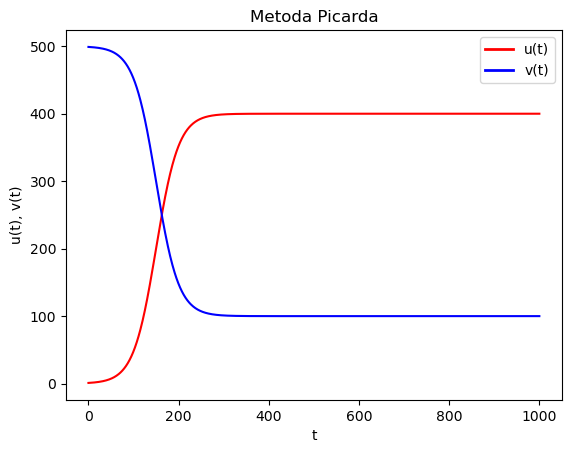

In [14]:
picardLegend = ('Metoda Picarda', ('red', 'blue'))
drawPlot(pt, pu, pt, pv, picardLegend)

- Metoda Newtona

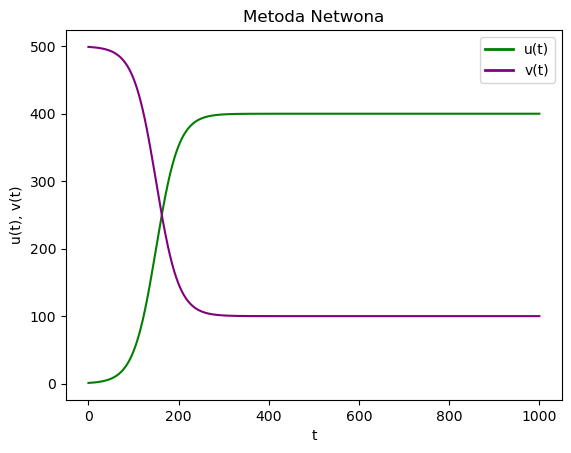

In [15]:
newtonLegend = ('Metoda Netwona', ('green', 'purple'))
drawPlot(nt, nu, nt, nv, newtonLegend)

# Niejawna Metoda KR2

In [16]:
a11 = 1 / 4
a12 = 1 / 4 - np.sqrt(3) / 6
a21 = 1 / 4 + np.sqrt(3) / 6
a22 = 1 / 4
b1 = 1 / 2
b2 = 1 / 2
c1 = 1 / 2 - np.sqrt(3) / 6
c1 = 1 / 2 + np.sqrt(3) / 6

def kr2PostStep(un: np.ndarray[np.double], uc: np.ndarray[np.double]) -> np.ndarray[np.double]:
    un[0] = uc[0] + dT * (b1 * f(uc[1]) + b2 * f(uc[2]))
    un[1:] = un[0]
    return uc

def kr2IteracionStep(un: np.ndarray[np.double], uc: np.ndarray[np.double]) -> tuple[np.ndarray[np.double], np.ndarray[np.double]]:
    b = lambda a1, a2: a1 * (ALPHA * uc[1] - BETA * uc[1] * uc[1]) + a2 * (ALPHA * uc[2] - BETA * uc[2] * uc[2])
    F1 = uc[1] - uc[0] - dT * b(a11, a12)
    F2 = uc[2] - uc[0] - dT * b(a21, a22)
    m11 = 1 - dT * a11 * (ALPHA - 2 * BETA * uc[1])
    m12 = -dT * a12 * (ALPHA - 2 * BETA * uc[2])
    m21 = -dT * a21 * (ALPHA - 2 * BETA * uc[1])
    m22 = 1 - dT * a22 * (ALPHA - 2 * BETA * uc[2])
    dU1 = (F2 * m12 - F1 * m22) / (m11 * m22 - m12 * m21)
    dU2 = (F1 * m21 - F2 * m11) / (m11 * m22 - m12 * m21)
    uc[1:] += [dU1, dU2]
    return un, uc

krt, kru = trapezoidalMethod(3, kr2IteracionStep, kr2PostStep)
krv = np.full_like(kru[:, 0], N) - kru[:, 0]

##### Wykresy

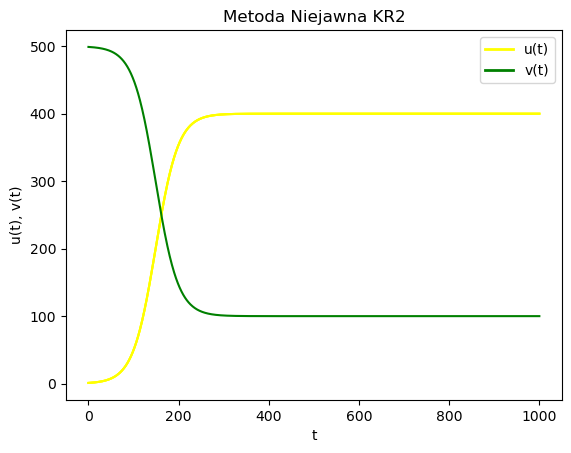

In [17]:
KR2Legend = ('Metoda Niejawna KR2', ('yellow', 'green'))
drawPlot(krt, kru, krt, krv, KR2Legend)